In [1]:
import pandas as pd
df = pd.read_csv("EV_Fleet_10000_Rows.csv")

In [2]:
df.head()

,Car_ID,Manufacturer,Car_Model,Driver,Battery_Capacity_kWh,Battery_Percentage,Battery_Health,Expected_Distance_KM,Max_Speed_KMH,Instantaneous_Speed_KMH,...,KM_Travelled,Energy_Consumption_Rate,Year_Manufactured,Maintenance_Cost,Charging,Running,Charging_Cost,Garage,Garage_Status,Timestamp
0,EV0047,MG,ZS EV,Driver_047,50.3,96.18,95.72,424.41,175,0,...,24979,0.17,2019,1189.37,1,0,250.82,Garage C,Charging,2025-01-01 01:48:00
1,EV0044,Hyundai,Kona EV,Driver_044,39.2,81.50,94.48,348.05,167,124,...,32622,0.16,2022,1644.16,0,1,0.00,Garage D,Working,2025-01-01 02:06:00
2,EV0015,MG,ZS EV,Driver_015,50.3,90.32,94.81,394.77,175,109,...,39460,0.17,2020,1591.30,0,1,0.00,Garage C,Working,2025-01-01 02:08:00
3,EV0031,MG,ZS EV,Driver_031,50.3,26.37,93.45,113.60,175,141,...,109902,0.17,2025,3750.56,0,1,0.00,Garage C,Working,2025-01-01 04:30:00
4,EV0049,Tesla,Model 3,Driver_049,60.0,10.95,92.35,50.56,225,0,...,28966,0.14,2023,1514.98,1,0,72.05,Garage A,Charging,2025-01-01 04:45:00


In [3]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [4]:
df['Year']=df['Timestamp'].dt.year
df['Month']=df['Timestamp'].dt.month
df['Date']=df['Timestamp'].dt.day
df['Hour']=df['Timestamp'].dt.hour

In [5]:
df.tail(20)

,Car_ID,Manufacturer,Car_Model,Driver,Battery_Capacity_kWh,Battery_Percentage,Battery_Health,Expected_Distance_KM,Max_Speed_KMH,Instantaneous_Speed_KMH,...,Charging,Running,Charging_Cost,Garage,Garage_Status,Timestamp,Year,Month,Date,Hour
9980,EV0030,Tata,Nexon EV,Driver_030,40.5,92.73,97.35,419.77,120,63,...,0,1,0.00,Garage B,Parked,2025-12-31 07:45:00,2025,12,31,7
9981,EV0004,Hyundai,Kona EV,Driver_004,39.2,91.07,88.34,363.64,167,0,...,1,0,262.36,Garage D,Charging,2025-12-31 07:45:00,2025,12,31,7
9982,EV0029,Tesla,Model 3,Driver_029,60.0,15.37,90.22,69.33,225,0,...,1,0,55.35,Garage A,Charging,2025-12-31 08:03:00,2025,12,31,8
9983,EV0008,Hyundai,Kona EV,Driver_008,39.2,63.32,97.41,278.79,167,124,...,0,1,0.00,Garage D,Working,2025-12-31 08:40:00,2025,12,31,8
9984,EV0027,MG,ZS EV,Driver_027,50.3,56.75,88.48,231.48,175,34,...,0,1,0.00,Garage C,Working,2025-12-31 09:19:00,2025,12,31,9
9985,EV0036,Hyundai,Kona EV,Driver_036,39.2,33.77,85.72,130.84,167,15,...,0,1,0.00,Garage D,Working,2025-12-31 10:30:00,2025,12,31,10
9986,EV0010,Tata,Nexon EV,Driver_010,40.5,32.24,86.12,129.11,120,62,...,0,1,0.00,Garage B,Working,2025-12-31 10:48:00,2025,12,31,10
9987,EV0036,Hyundai,Kona EV,Driver_036,39.2,92.45,85.72,358.20,167,133,...,0,1,0.00,Garage D,Working,2025-12-31 10:50:00,2025,12,31,10
9988,EV0049,Tesla,Model 3,Driver_049,60.0,19.07,92.35,88.06,225,0,...,1,0,43.71,Garage A,Charging,2025-12-31 14:07:00,2025,12,31,14
9989,EV0029,Tesla,Model 3,Driver_029,60.0,13.48,90.22,60.81,225,0,...,1,0,373.93,Garage A,Charging,2025-12-31 14:10:00,2025,12,31,14


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [7]:
running_count = df[df['Running']==1]['Car_ID'].nunique()
print("Running Vehicles:", running_count)

Running Vehicles: 50


In [8]:
garage_count = df.groupby('Garage')['Car_ID'].nunique()
print(garage_count)

Garage
Garage A    13
Garage B    13
Garage C    12
Garage D    12
Name: Car_ID, dtype: int64


In [9]:
max_car = df.loc[df['KM_Travelled'].idxmax(), 'Car_ID']

print("Vehicle with Maximum KM Travelled:", max_car)

Vehicle with Maximum KM Travelled: EV0037


In [10]:
car_km = (
    df.groupby('Car_ID')['KM_Travelled']
    .max()
    .reset_index()
    .sort_values(
        by='KM_Travelled',
        ascending=False
    )
)

print(car_km)

    Car_ID  KM_Travelled
36  EV0037        245899
24  EV0025        235616
18  EV0019        204887
9   EV0010        194707
21  EV0022        175714
35  EV0036        173471
25  EV0026        171260
32  EV0033        166540
8   EV0009        158385
39  EV0040        153014
20  EV0021        146651
3   EV0004        139917
47  EV0048        135750
27  EV0028        133506
38  EV0039        127085
15  EV0016        123363
0   EV0001        115166
30  EV0031        110174
44  EV0045        107984
17  EV0018        102177
26  EV0027         99115
23  EV0024         90555
34  EV0035         88687
1   EV0002         86951
31  EV0032         84247
6   EV0007         84244
19  EV0020         83453
28  EV0029         76161
16  EV0017         75303
5   EV0006         71584
12  EV0013         62700
10  EV0011         61867
42  EV0043         61689
49  EV0050         55284
11  EV0012         49549
45  EV0046         47877
33  EV0034         41151
14  EV0015         40023
43  EV0044         36877


In [11]:
car_km.count()

Car_ID          50
KM_Travelled    50
dtype: int64

In [12]:
latest_df = df.loc[
    df.groupby('Car_ID')['KM_Travelled'].idxmax()
]

print(latest_df.shape)

(50, 26)


In [13]:
running_count = latest_df['Running'].sum()

print("Running Vehicles:", running_count)

Running Vehicles: 35


In [14]:
charging_count = latest_df['Charging'].sum()

print("Charging Vehicles:", charging_count)

Charging Vehicles: 15


In [15]:
garage_count = latest_df.groupby(
    'Garage'
)['Car_ID'].count()

print(garage_count)

Garage
Garage A    13
Garage B    13
Garage C    12
Garage D    12
Name: Car_ID, dtype: int64


In [16]:
manufacturer_count = latest_df.groupby(
    'Manufacturer'
)['Car_ID'].count()

print(manufacturer_count)

Manufacturer
Hyundai    12
MG         12
Tata       13
Tesla      13
Name: Car_ID, dtype: int64


In [17]:
garage_status = latest_df[
    'Garage_Status'
].value_counts()

print(garage_status)

Garage_Status
Working     24
Charging    15
Parked      11
Name: count, dtype: int64


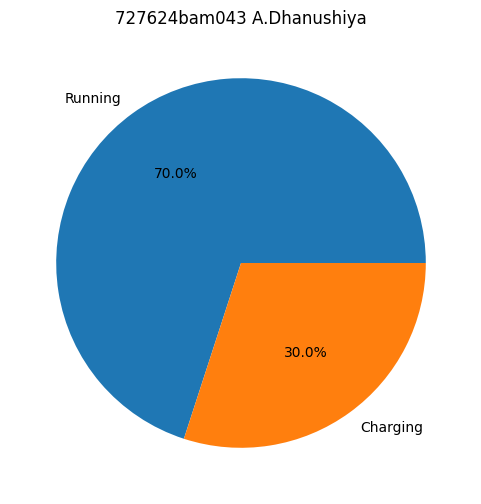

In [20]:
status = {
    "Running": latest_df['Running'].sum(),
    "Charging": latest_df['Charging'].sum()
}

plt.figure(figsize=(6,6))

plt.pie(
    status.values(),
    labels=status.keys(),
    autopct='%1.1f%%'
)

plt.title(

    "727624bam043 A.Dhanushiya"
    

)

plt.show()

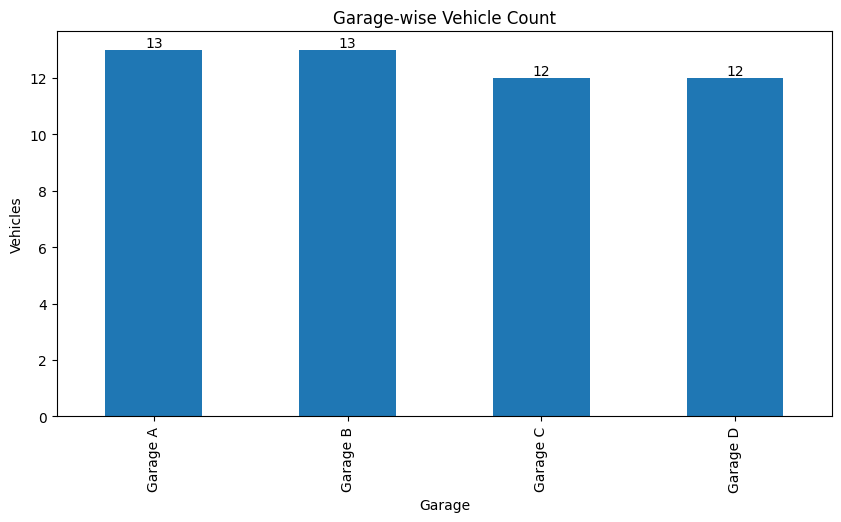

In [19]:
plt.figure(figsize=(10,5))

ax = garage_count.plot(
    kind='bar'
)

plt.title("Garage-wise Vehicle Count")
plt.ylabel("Vehicles")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

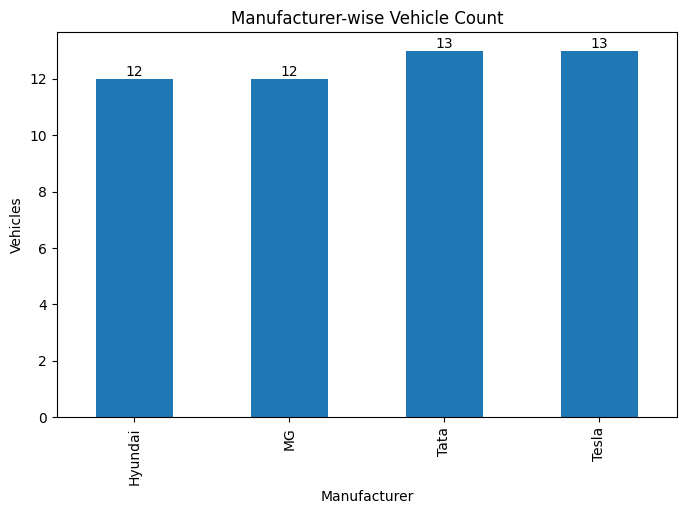

In [22]:
plt.figure(figsize=(8,5))

ax = manufacturer_count.plot(
    kind='bar'
)

plt.title("Manufacturer-wise Vehicle Count")
plt.ylabel("Vehicles")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [23]:
df['Month'] = df['Timestamp'].dt.strftime('%b')

monthly_revenue = (
    df.groupby(['Car_ID','Month'])['Revenue']
    .sum()
    .reset_index()
)

print(monthly_revenue)

     Car_ID Month  Revenue
0    EV0001   Apr  5308.51
1    EV0001   Aug  5534.06
2    EV0001   Dec  2094.24
3    EV0001   Feb  3850.92
4    EV0001   Jan  4986.04
..      ...   ...      ...
595  EV0050   Mar  1722.61
596  EV0050   May  6923.04
597  EV0050   Nov  3929.56
598  EV0050   Oct  2789.98
599  EV0050   Sep  6289.13

[600 rows x 3 columns]


In [24]:
monthly_maintenance = (
    df.groupby(['Car_ID','Month'])
    ['Maintenance_Cost']
    .sum()
    .reset_index()
)

print(monthly_maintenance)

     Car_ID Month  Maintenance_Cost
0    EV0001   Apr          65074.11
1    EV0001   Aug          73970.74
2    EV0001   Dec          43518.38
3    EV0001   Feb          60741.79
4    EV0001   Jan          78160.71
..      ...   ...               ...
595  EV0050   Mar          29249.61
596  EV0050   May          32891.52
597  EV0050   Nov          31438.59
598  EV0050   Oct          27403.98
599  EV0050   Sep          38393.52

[600 rows x 3 columns]


In [25]:
driver_revenue = (
    df.groupby('Driver')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

max_driver = driver_revenue.idxmax()
max_revenue = driver_revenue.max()

print("Driver :", max_driver)
print("Revenue :", max_revenue)

Driver : Driver_029
Revenue : 60700.71


In [26]:
driver_revenue = (
    df.groupby('Driver')['Revenue']
    .sum()
    .sort_values(ascending=True)
)

min_driver = driver_revenue.idxmin()
min_revenue = driver_revenue.min()

print("Driver :", min_driver)
print("Revenue :", min_revenue)

Driver : Driver_006
Revenue : 41220.9


In [27]:
df['Overspeed'] = (
    df['Instantaneous_Speed_KMH']
    >=
    (0.90 * df['Max_Speed_KMH'])
)

In [28]:
df['Overspeed']

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999     True
Name: Overspeed, Length: 10000, dtype: bool

In [29]:
overspeed_count = (
    df[df['Overspeed']]
    .groupby('Driver')
    .size()
    .sort_values(ascending=False)
)

print(overspeed_count.head())

Driver
Driver_015    22
Driver_045    22
Driver_043    20
Driver_046    20
Driver_038    19
dtype: int64


In [30]:
max_violation_driver = overspeed_count.idxmax()

max_violation_count = overspeed_count.max()

print(
    max_violation_driver,
    max_violation_count
)

Driver_015 22


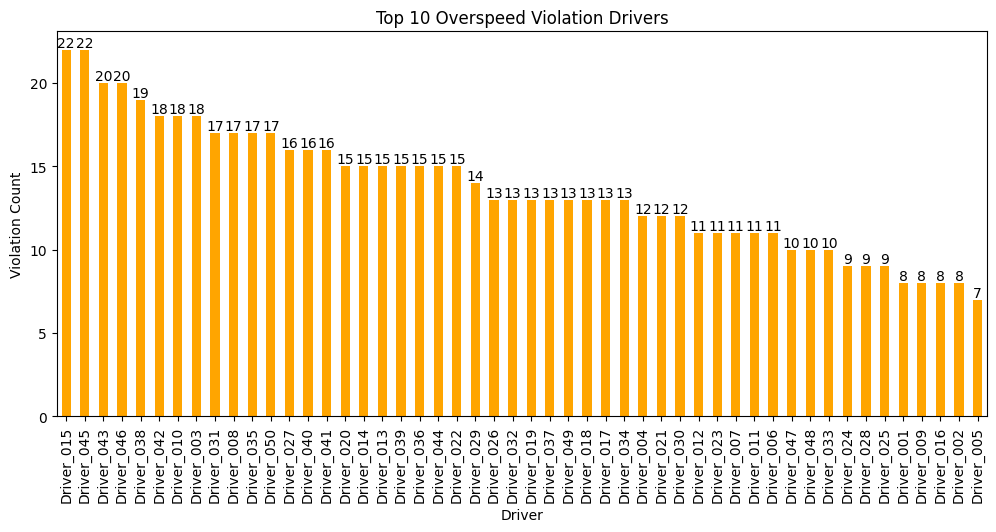

In [31]:
top10_violation = overspeed_count

plt.figure(figsize=(12,5))

ax = top10_violation.plot(
    kind='bar',
    color='orange'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Overspeed Violation Drivers"
)

plt.ylabel(
    "Violation Count"
)

plt.show()

In [32]:
running_vehicles = latest_df[
    latest_df['Running'] == 1
]

print(
    running_vehicles[
        ['Car_ID','Driver','Manufacturer','Garage']
    ]
)

      Car_ID      Driver Manufacturer    Garage
7157  EV0001  Driver_001        Tesla  Garage A
4622  EV0002  Driver_002         Tata  Garage B
7229  EV0006  Driver_006         Tata  Garage B
7940  EV0008  Driver_008      Hyundai  Garage D
3919  EV0009  Driver_009        Tesla  Garage A
3622  EV0010  Driver_010         Tata  Garage B
3548  EV0011  Driver_011           MG  Garage C
4167  EV0012  Driver_012      Hyundai  Garage D
9161  EV0014  Driver_014         Tata  Garage B
438   EV0015  Driver_015           MG  Garage C
9299  EV0016  Driver_016      Hyundai  Garage D
2225  EV0021  Driver_021        Tesla  Garage A
5016  EV0022  Driver_022         Tata  Garage B
3957  EV0023  Driver_023           MG  Garage C
643   EV0025  Driver_025        Tesla  Garage A
1929  EV0026  Driver_026         Tata  Garage B
4639  EV0028  Driver_028      Hyundai  Garage D
9632  EV0029  Driver_029        Tesla  Garage A
6714  EV0030  Driver_030         Tata  Garage B
7405  EV0033  Driver_033        Tesla  G

In [33]:
running_count = latest_df['Running'].sum()

print("Running Vehicles:", running_count)

Running Vehicles: 35


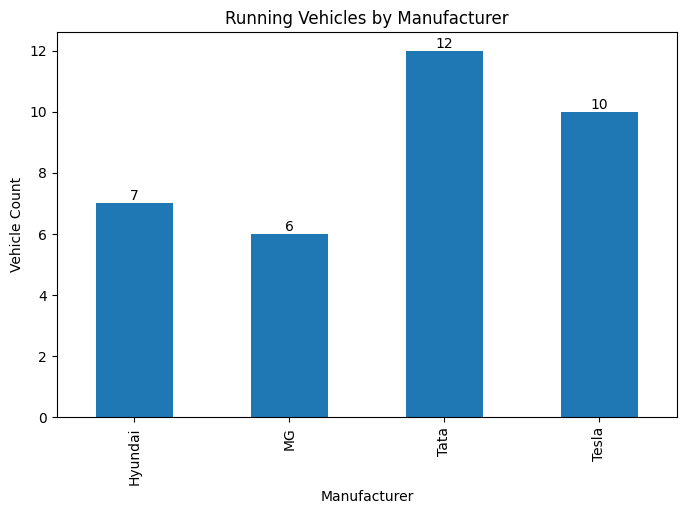

In [34]:
import matplotlib.pyplot as plt

running_by_manufacturer = (
    latest_df[latest_df['Running']==1]
    .groupby('Manufacturer')['Car_ID']
    .count()
)

ax = running_by_manufacturer.plot(
    kind='bar',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Running Vehicles by Manufacturer")
plt.ylabel("Vehicle Count")
plt.xlabel("Manufacturer")

plt.show()